# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [42]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

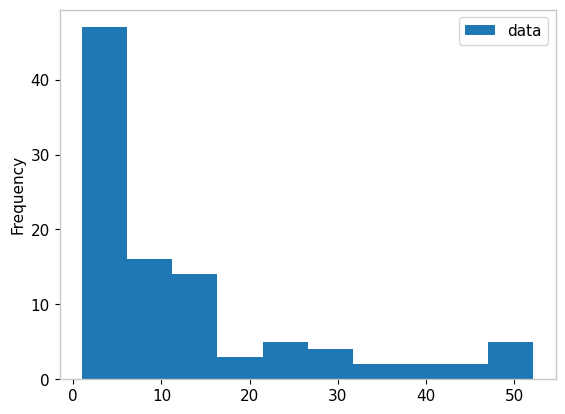

In [43]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

Pros: 
- We can clearly see that there are more drugs with prices close to zero than there are more expensive drugs so the data is right skewed. 
- We can see that most drugs are between 0 and 20 dollars with a few outliers.

Cons: 
- The X axis is not labeled so all we can do is assume the units are $.
- There is no chart title. 
- We can't clearly see the mean or the median drug price from the figure.
- We can't see the 75th percentile by looking at the chart 

<Axes: >

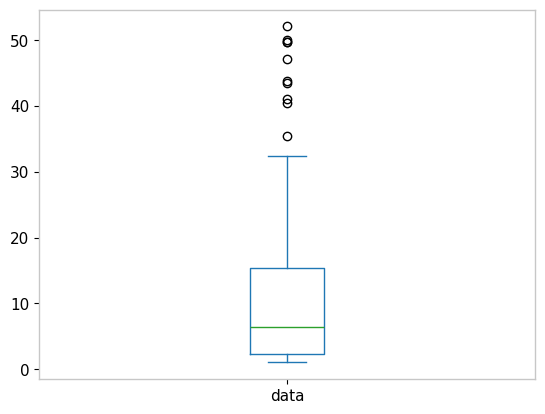

In [44]:
df.plot.box()

Pros: 
- We can clearly see the IQR range, the median, and the first and third quartiles. 
- We can easily see the outliers towards the top of the figure

Cons
- The chart does not have a title so we do not know exactly what we are looking at. 
- We can't see the distribution shape as clearly. 
- The box plot is less intuitive than the histogram/ 

I would choose the histogram because the administrator wants to see drug prices in the context of other prices and the histogram does a great job of showing the left skew in the data. I believe the shape of the data is important and want to preserve that for the administrator. Also, histograms are more intuitive to non-technical audiences than box plots. 

I would add a title to the historgram that clearly lets us know what the chart is showing. I would also add an x axis label. I would also add a summary box with key statistics such as the 25 and 75th percentiles along with the median. 

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [65]:
df = pd.read_csv("CLimate_change_dataset.csv")

In [66]:
df_numeric_columns = df.drop(columns = ['Country','Year'])

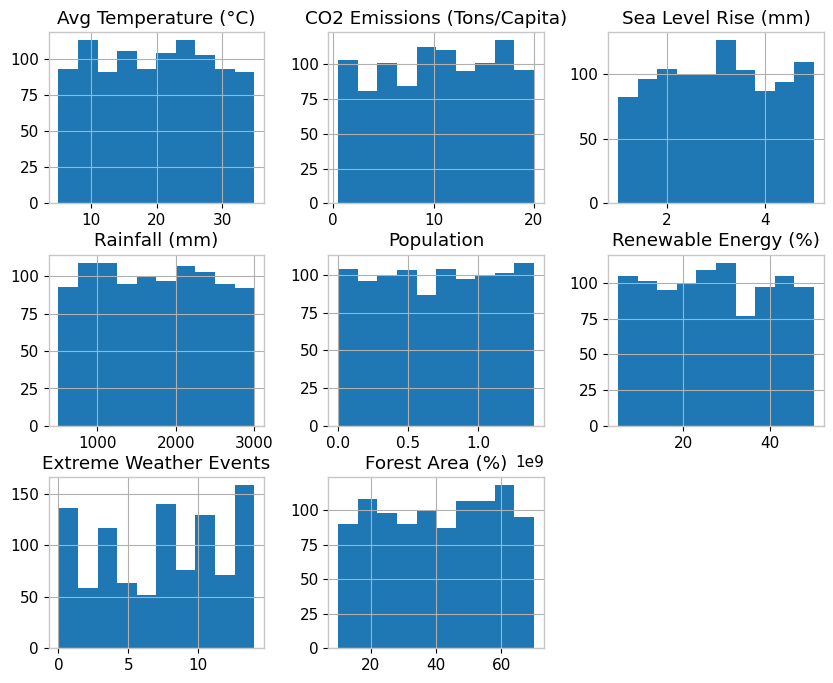

In [67]:
#drawing histograms for each column
df_numeric_columns.hist(figsize=(10, 8))
None

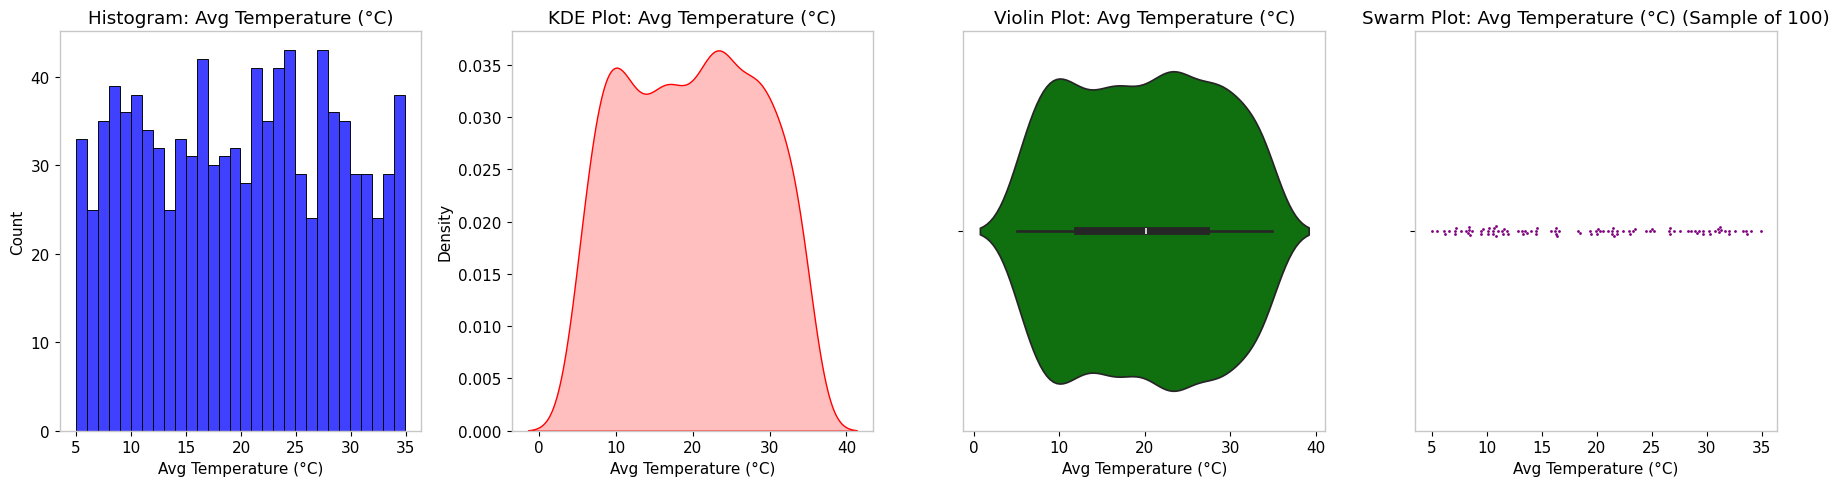

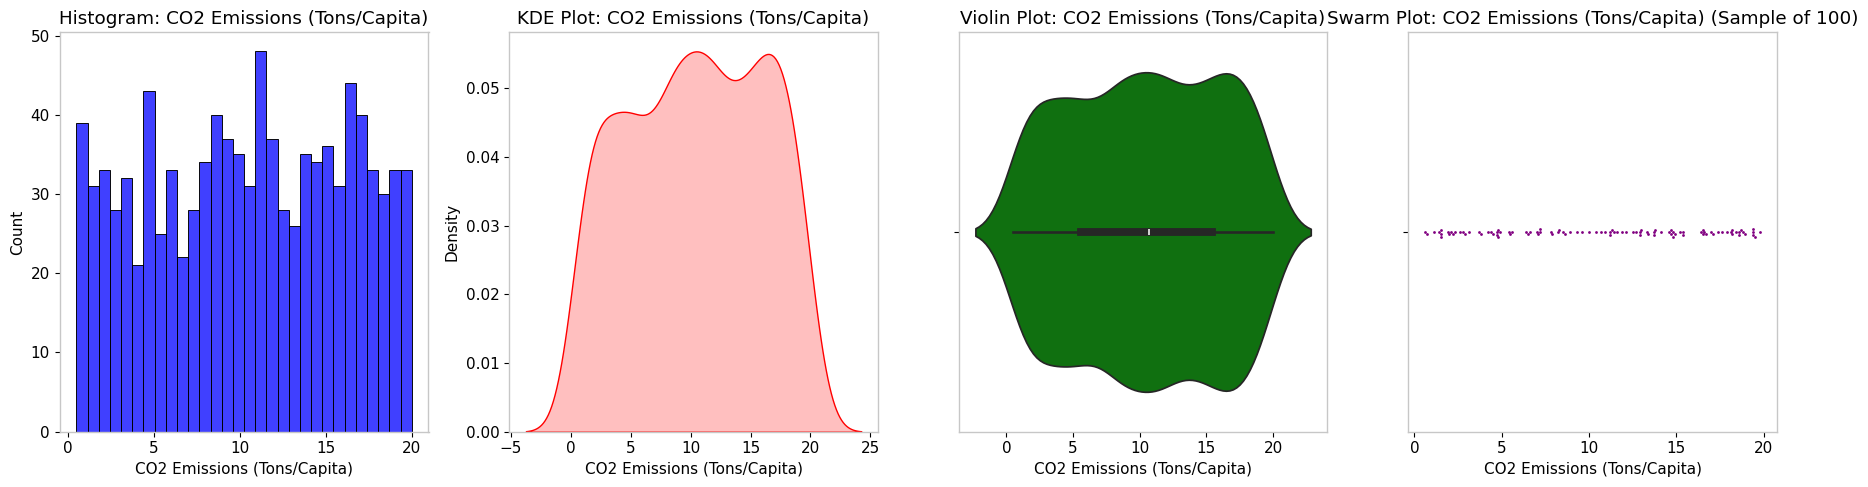

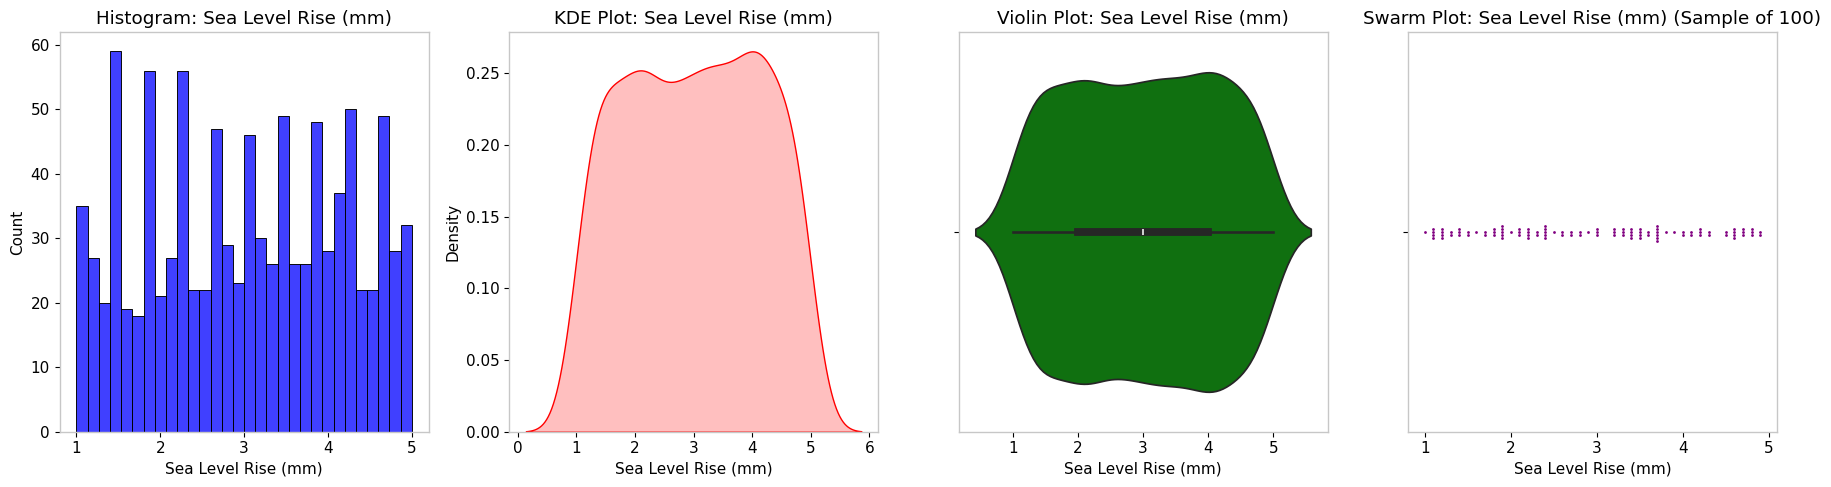

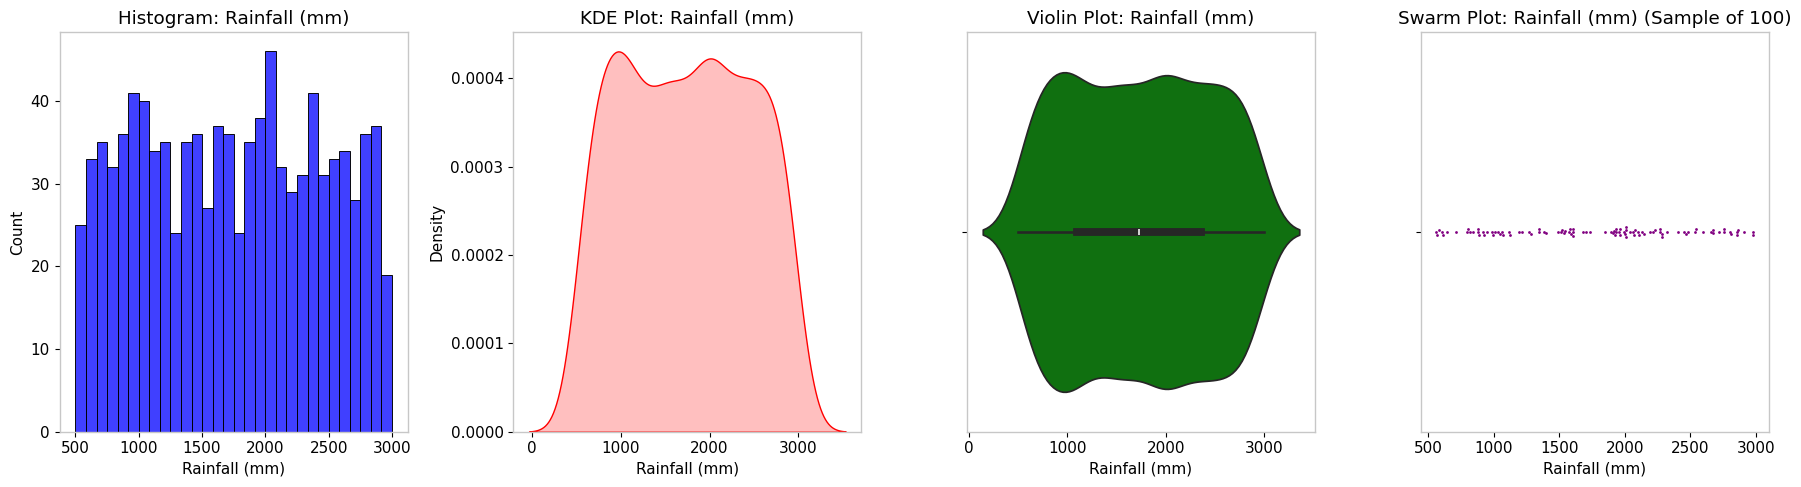

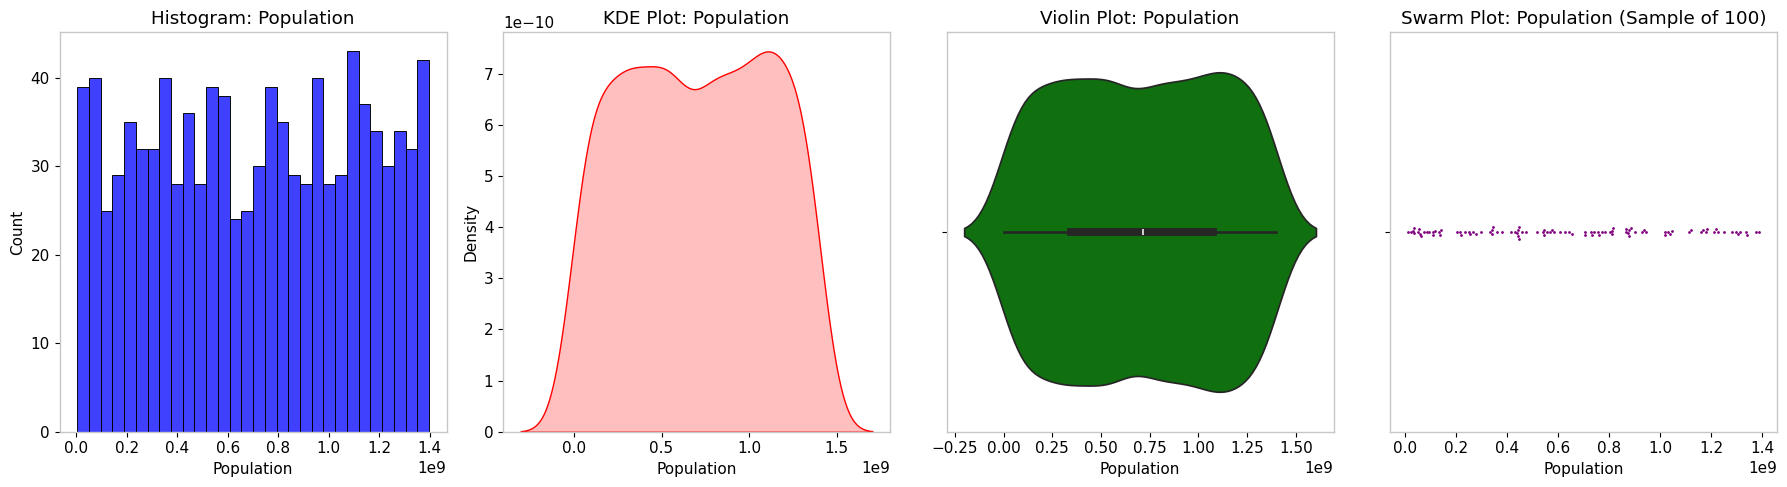

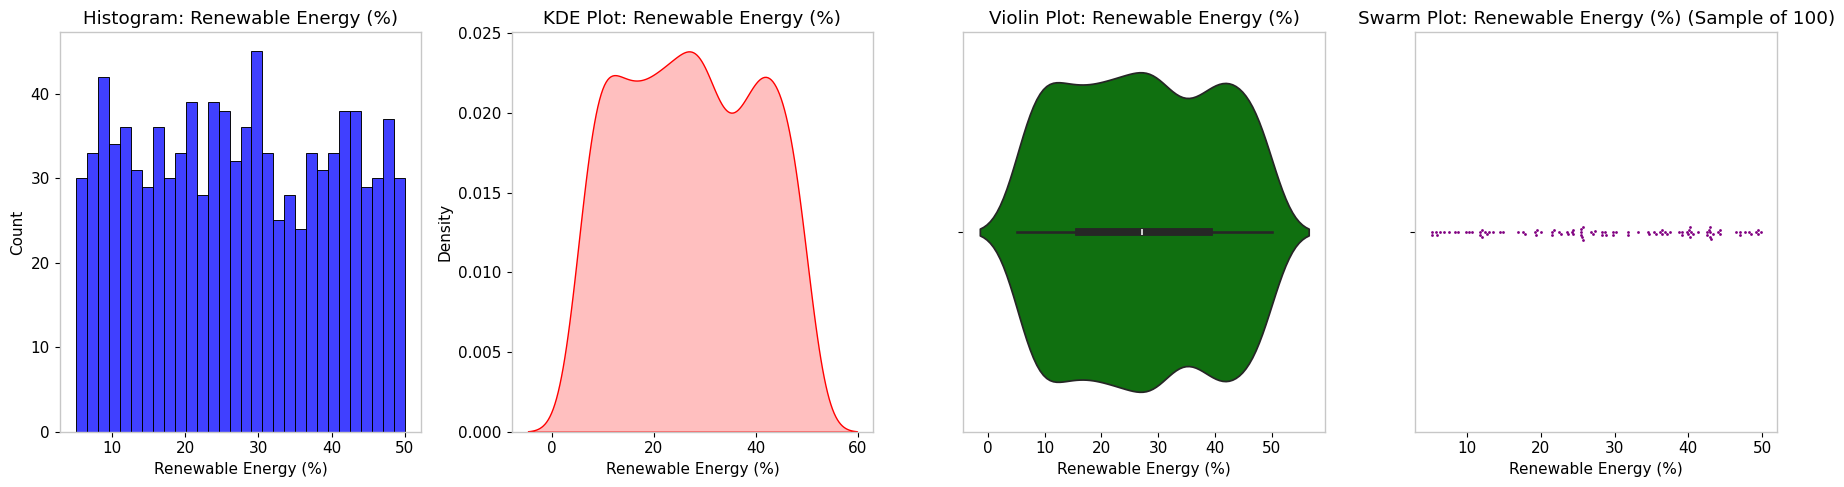

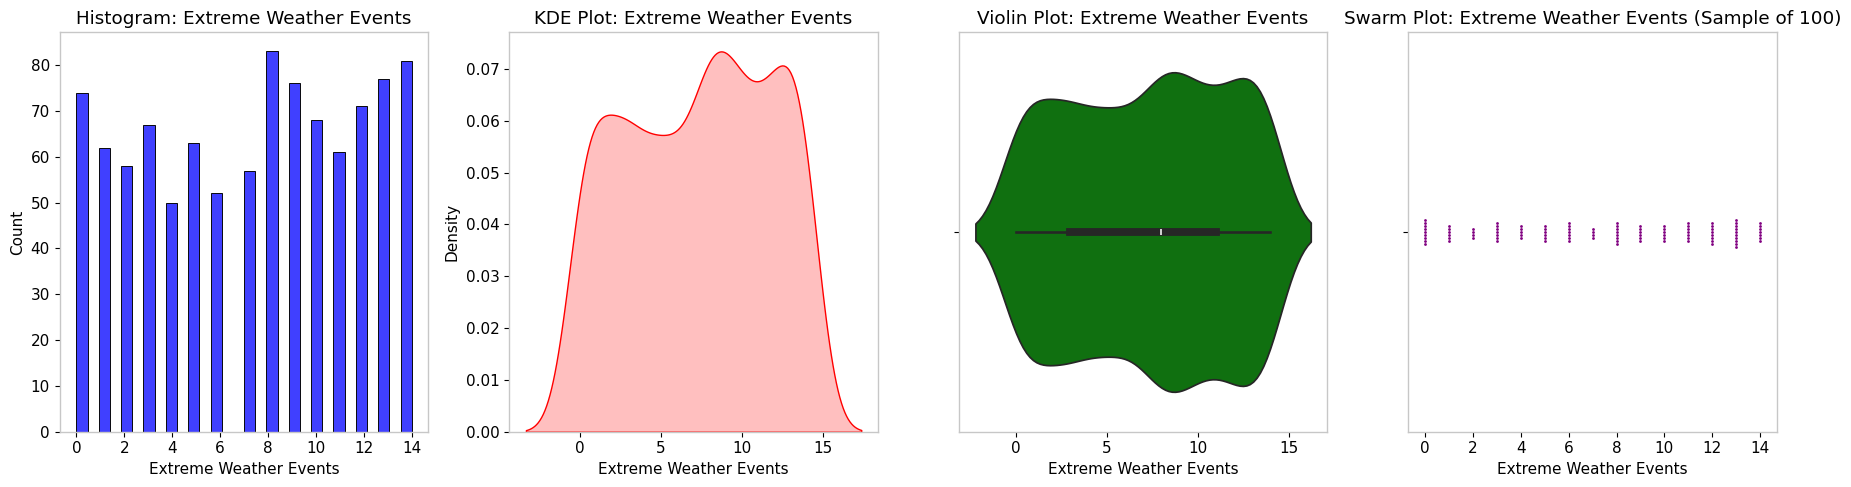

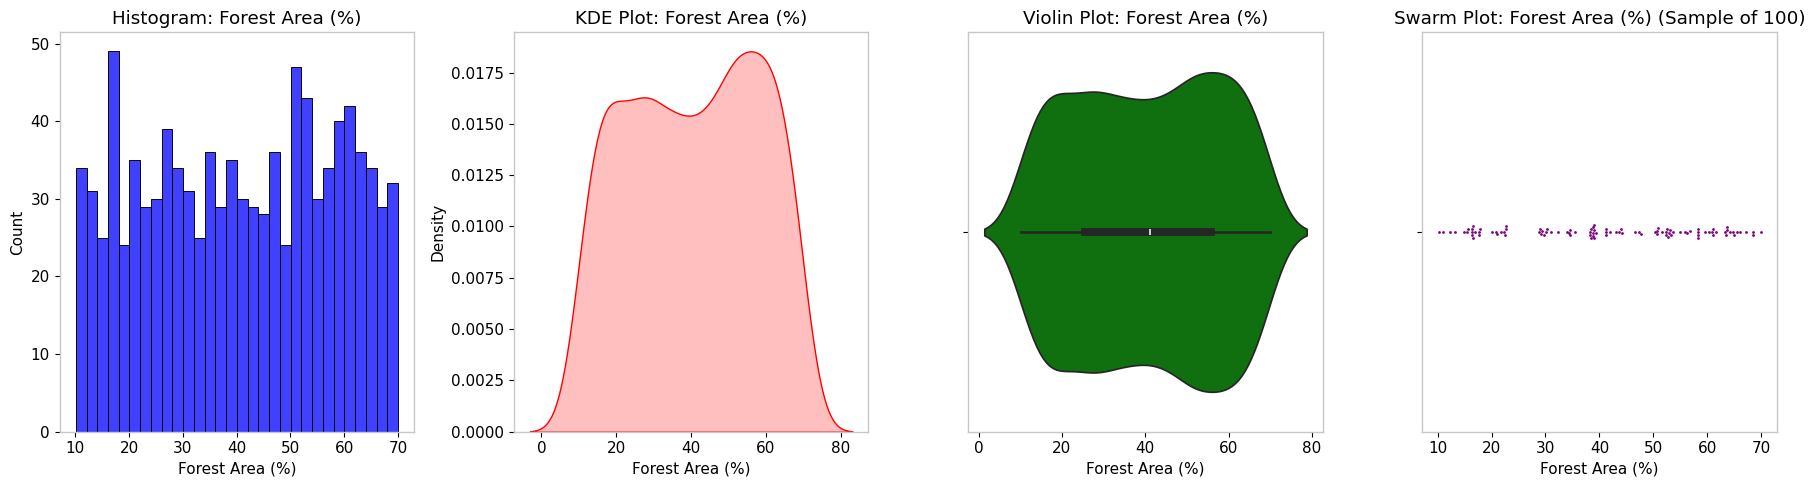

In [69]:
import seaborn as sns 

#drawing histograms variants for each column

for col in df_numeric_columns.columns: 
    plt.figure(figsize=(18, 5))

    # Histogram
    plt.subplot(1, 4, 1)
    sns.histplot(df_numeric_columns[col], bins=30, kde=False, color='blue')
    plt.title(f'Histogram: {col}')

    # KDE Plot
    plt.subplot(1, 4, 2)
    sns.kdeplot(df_numeric_columns[col], fill=True, color='red')
    plt.title(f'KDE Plot: {col}')

    # Violin Plot
    plt.subplot(1, 4, 3)
    sns.violinplot(x=df_numeric_columns[col], color='green')
    plt.title(f'Violin Plot: {col}')

    plt.subplot(1, 4, 4)
    sns.swarmplot(x=df_numeric_columns[col].sample(n=100, random_state=0), color='purple', size=2)
    plt.title(f'Swarm Plot: {col} (Sample of 100)')

    plt.tight_layout()
    plt.show()

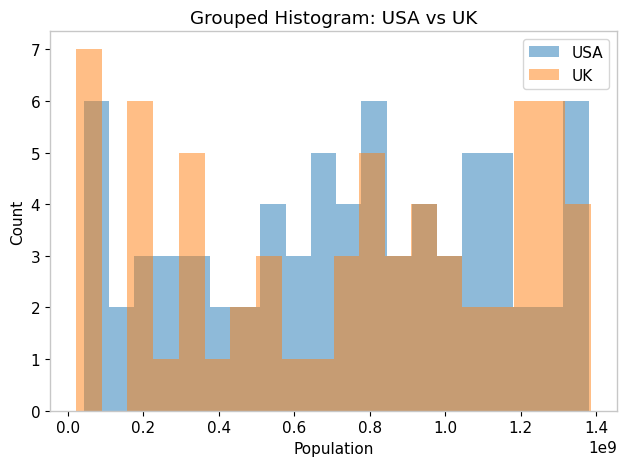

In [107]:
import matplotlib.pyplot as plt
import numpy as np

usa = df.query("Country == 'USA'")['Population'].dropna()
uk  = df.query("Country == 'UK'")['Population'].dropna()

bins = np.histogram_bin_edges(
    pd.concat([usa, uk]))

plt.hist(usa, bins=20, alpha=0.5, label="USA")
plt.hist(uk,  bins=20, alpha=0.5, label="UK")

plt.xlabel("Population")
plt.ylabel("Count")
plt.title("Grouped Histogram: USA vs UK")
plt.legend()
plt.tight_layout()
plt.show()

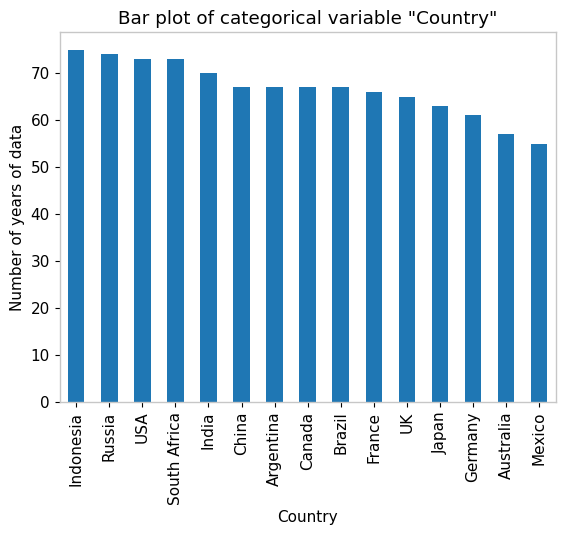

In [93]:
df.Country.value_counts().plot(kind = 'bar')
plt.ylabel("Number of years of data")
plt.title('Bar plot of categorical variable "Country"')
None

In [ ]:
#find means, medians, and modes 
means = df_numeric_columns.mean()
medians = df_numeric_columns.median()
modes = df_numeric_columns.mode().iloc[0]

Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- The data matches what I expections for a climate change related data set. For example, the temperature ranges are all realisitic and the sea level rises are all less than 5 mm.    

What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Overall most of the columns have a uniform distribution. 

Are there any outliers present?  (Data points that are far from the others.)

- There are no obvious outliers.

If there are multiple related histograms, how does the distribution change across different groups? 
- The distribution for population amongst UK and USA is about the same and does not change. 

How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?
- Changing the bin width does not reveal any different patterns in the data. 

Does the distribution appear normal, or does it have a different distribution?
- Looking at the KDE plots the overall distribution looks normal but there are some bimodal peaks in the data

In [104]:
#What are the minimum and maximum values represented in each histogram?
for col in df_numeric_columns:
    print(f"{col} : Min = {df[col].min()} Max = {df[col].max()}" )


Avg Temperature (°C) : Min = 5.0 Max = 34.9
CO2 Emissions (Tons/Capita) : Min = 0.5 Max = 20.0
Sea Level Rise (mm) : Min = 1.0 Max = 5.0
Rainfall (mm) : Min = 501 Max = 2999
Population : Min = 3660891 Max = 1397016073
Renewable Energy (%) : Min = 5.1 Max = 50.0
Extreme Weather Events : Min = 0 Max = 14
Forest Area (%) : Min = 10.1 Max = 70.0


# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

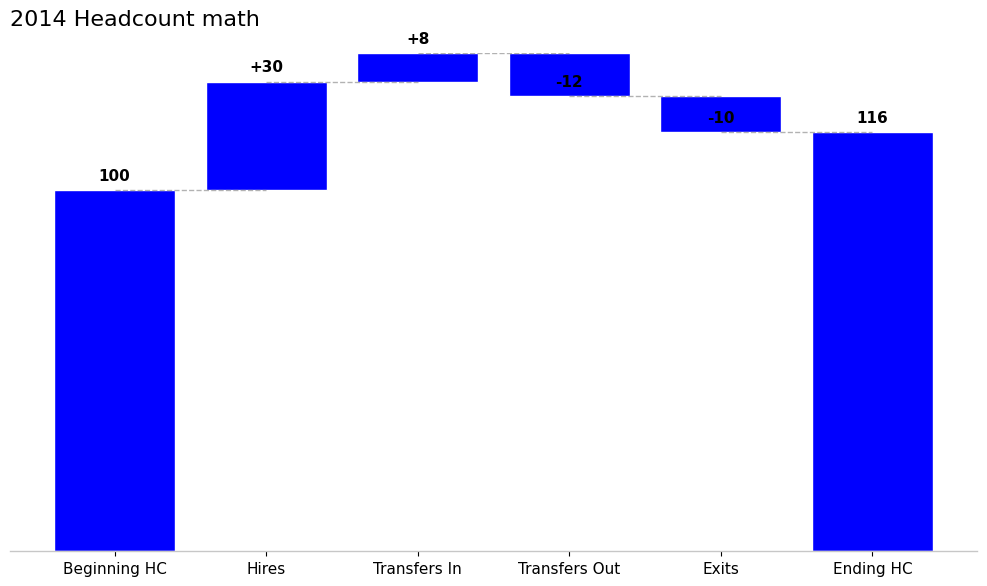

In [45]:
import matplotlib.pyplot as plt
import pandas as pd

data = [
    ['Beginning HC', 100],
    ['Hires', 30],
    ['Transfers In', 8],
    ['Transfers Out', -12],
    ['Exits', -10],
    ['Ending HC', 116]
]
df = pd.DataFrame(data, columns=['Label', 'Value'])


cumulative = df['Value'].cumsum().shift(1).fillna(0)

bottoms = cumulative.copy()
bottoms.iloc[0] = 0
bottoms.iloc[-1] = 0

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['blue'] * len(df)

bars = ax.bar(df['Label'], df['Value'], bottom=bottoms, color=colors, edgecolor='white')

for i in range(len(df) - 1):
    y_level = cumulative.iloc[i+1]
    ax.plot([i, i + 1], [y_level, y_level], color='grey', linestyle='--', linewidth=1, alpha=0.6)

ax.set_title('2014 Headcount math', loc='left', fontsize=16, pad=20)

for i, bar in enumerate(bars):
    height = bar.get_height()
    y_pos = bar.get_y() + height
    label = f"{height:+g}" if 0 < i < len(df)-1 else f"{int(height)}"
    
    ax.text(bar.get_x() + bar.get_width()/2, y_pos + 2, label, 
            ha='center', va='bottom', fontsize=11, color='black', fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.get_yaxis().set_visible(False)

plt.tight_layout()
plt.show()
